# agentv12_rag_agent — Fixed RAG with Idempotent Chroma Ingestion

This version fixes the Chroma error:

```text
attempt to write a readonly database
```

The fix is: do not delete/recreate Chroma while the notebook may still hold an open vector store connection.

Instead:

```text
if chroma_db exists → reuse
else → create
```


## 1. Install dependencies

```bash
pip install -U langgraph langchain langchain-openai langchain-community langchain-chroma chromadb pypdf reportlab langsmith python-dotenv ipython jupyter
```


In [1]:
# Optional: uncomment in a fresh environment.
# %pip install -U langgraph langchain langchain-openai langchain-community langchain-chroma chromadb pypdf reportlab langsmith python-dotenv ipython jupyter


## 2. Load environment variables


In [2]:
from pathlib import Path
import os
from dotenv import load_dotenv

cwd = Path.cwd()
load_dotenv(cwd / ".env")
load_dotenv(cwd.parent / ".env")

print("OpenAI API key present:", bool(os.getenv("OPENAI_API_KEY")))
print("LangSmith tracing:", os.getenv("LANGSMITH_TRACING"))
print("LangSmith project:", os.getenv("LANGSMITH_PROJECT"))


OpenAI API key present: True
LangSmith tracing: true
LangSmith project: langgraph-playground


## 3. Define paths and state


In [3]:
from pathlib import Path
from typing import TypedDict

DOCS_DIR = Path("docs")
CHROMA_DIR = Path("chroma_db")
COLLECTION_NAME = "epp_rag_docs"

class AgentState(TypedDict, total=False):
    input: str
    documents_loaded: bool
    retrieved_context: list[str]
    answer: str


## 4. PDF writer and sample PDF creation


In [4]:
from reportlab.lib.pagesizes import letter
from reportlab.pdfgen import canvas

def write_pdf(path: Path, title: str, paragraphs: list[str]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    c = canvas.Canvas(str(path), pagesize=letter)
    width, height = letter

    y = height - 72
    c.setFont("Helvetica-Bold", 16)
    c.drawString(72, y, title)
    y -= 36

    c.setFont("Helvetica", 10)
    for paragraph in paragraphs:
        words = paragraph.split()
        line = ""
        for word in words:
            if len(line + " " + word) > 92:
                c.drawString(72, y, line)
                y -= 14
                line = word
                if y < 72:
                    c.showPage()
                    c.setFont("Helvetica", 10)
                    y = height - 72
            else:
                line = f"{line} {word}".strip()
        if line:
            c.drawString(72, y, line)
            y -= 20
        if y < 72:
            c.showPage()
            c.setFont("Helvetica", 10)
            y = height - 72

    c.save()

def create_sample_pdfs() -> list[Path]:
    DOCS_DIR.mkdir(parents=True, exist_ok=True)

    runbook = DOCS_DIR / "epp_runbook.pdf"
    release_notes = DOCS_DIR / "epp_release_notes.pdf"

    write_pdf(
        runbook,
        "EPP SLA Operations Runbook",
        [
            "When CHECK-DOMAIN requests show elevated CONNECTION_TIMEOUT failures, first inspect upstream registry connectivity, DNS resolver latency, and client retry behavior.",
            "If response_time increases together with timeout volume, prioritize network path checks and registry endpoint health before application code changes.",
            "For ADD-DOMAIN AUTH_FAILED spikes, inspect credential rotation, client authentication configuration, and recent changes to access-control rules.",
            "Recommended incident workflow: compare failure volume before and after the release window, group failures by command and failed_reason, then identify the dominant client_name and tld.",
        ],
    )

    write_pdf(
        release_notes,
        "EPP Release R13 Notes",
        [
            "Release R13 was deployed from 2026-06-20 through 2026-06-22 in us-east-1.",
            "The release included registry connection pool changes, timeout tuning, and additional telemetry for CHECK-DOMAIN and ADD-DOMAIN commands.",
            "Known risk: CHECK-DOMAIN latency may increase if connection pool saturation occurs during peak traffic hours.",
            "Rollback criteria: sustained CONNECTION_TIMEOUT failure volume above baseline for two consecutive hours or response_time above 220 milliseconds for CHECK-DOMAIN.",
        ],
    )

    return [runbook, release_notes]

pdf_paths = create_sample_pdfs()
pdf_paths


[PosixPath('docs/epp_runbook.pdf'), PosixPath('docs/epp_release_notes.pdf')]

## 5. Load and split PDFs


In [5]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter

def load_and_split_pdfs(pdf_paths: list[Path]) -> list[Document]:
    docs: list[Document] = []

    for path in pdf_paths:
        loader = PyPDFLoader(str(path))
        docs.extend(loader.load())

    splitter = RecursiveCharacterTextSplitter(
        chunk_size=700,
        chunk_overlap=120,
    )

    return splitter.split_documents(docs)

chunks = load_and_split_pdfs(pdf_paths)

print("Chunks:", len(chunks))
print(chunks[0].page_content[:500])


/tmp/ipykernel_21213/1176995619.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


Chunks: 2
EPP SLA Operations Runbook
When CHECK-DOMAIN requests show elevated CONNECTION_TIMEOUT failures, first inspect upstream
registry connectivity, DNS resolver latency, and client retry behavior.
If response_time increases together with timeout volume, prioritize network path checks and
registry endpoint health before application code changes.
For ADD-DOMAIN AUTH_FAILED spikes, inspect credential rotation, client authentication
configuration, and recent changes to access-control rules.
Recommended i


## 6. Define vector store lifecycle helpers


In [6]:
import shutil
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings

def vector_store_exists() -> bool:
    return CHROMA_DIR.exists() and any(CHROMA_DIR.iterdir())

def reset_vector_store() -> None:
    # Use this manually only when no Chroma object is currently open.
    if CHROMA_DIR.exists():
        shutil.rmtree(CHROMA_DIR)

def create_vector_store() -> Chroma:
    pdf_paths = create_sample_pdfs()
    chunks = load_and_split_pdfs(pdf_paths)

    embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

    return Chroma.from_documents(
        documents=chunks,
        embedding=embeddings,
        collection_name=COLLECTION_NAME,
        persist_directory=str(CHROMA_DIR),
    )

def load_vector_store() -> Chroma:
    embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

    return Chroma(
        collection_name=COLLECTION_NAME,
        embedding_function=embeddings,
        persist_directory=str(CHROMA_DIR),
    )

def ensure_vector_store() -> None:
    create_sample_pdfs()

    if not vector_store_exists():
        create_vector_store()


## 7. Build or reuse vector store

This is idempotent.

It creates Chroma only if it does not already exist.


In [7]:
ensure_vector_store()
vector_store = load_vector_store()
print("Vector store ready:", vector_store_exists())


Vector store ready: True


## 8. Test retrieval directly


In [8]:
docs = vector_store.similarity_search(
    "What should we check when CHECK-DOMAIN timeouts increase?",
    k=4,
)

for doc in docs:
    print("---")
    print("source:", Path(doc.metadata.get("source", "unknown")).name)
    print("page:", doc.metadata.get("page"))
    print(doc.page_content)


---
source: epp_runbook.pdf
page: 0
EPP SLA Operations Runbook
When CHECK-DOMAIN requests show elevated CONNECTION_TIMEOUT failures, first inspect upstream
registry connectivity, DNS resolver latency, and client retry behavior.
If response_time increases together with timeout volume, prioritize network path checks and
registry endpoint health before application code changes.
For ADD-DOMAIN AUTH_FAILED spikes, inspect credential rotation, client authentication
configuration, and recent changes to access-control rules.
Recommended incident workflow: compare failure volume before and after the release window,
group failures by command and failed_reason, then identify the dominant client_name and tld.
---
source: epp_release_notes.pdf
page: 0
EPP Release R13 Notes
Release R13 was deployed from 2026-06-20 through 2026-06-22 in us-east-1.
The release included registry connection pool changes, timeout tuning, and additional
telemetry for CHECK-DOMAIN and ADD-DOMAIN commands.
Known risk: CHECK

## 9. Define graph nodes


In [9]:
from langchain_openai import ChatOpenAI

def ingest_pdfs_node(state: AgentState) -> AgentState:
    ensure_vector_store()
    return {"documents_loaded": True}

def retrieve_context_node(state: AgentState) -> AgentState:
    ensure_vector_store()
    vector_store = load_vector_store()

    docs = vector_store.similarity_search(
        state["input"],
        k=4,
    )

    context = [
        f"Source: {Path(doc.metadata.get('source', 'unknown')).name}, page {doc.metadata.get('page', 'unknown')}\n{doc.page_content}"
        for doc in docs
    ]

    return {"retrieved_context": context}

def generate_answer_node(state: AgentState) -> AgentState:
    llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

    context = "\n\n---\n\n".join(state.get("retrieved_context", []))

    prompt = f'''
You are an EPP operations assistant.

Answer the user question using only the retrieved context.
If the context is insufficient, say what is missing.

User question:
{state["input"]}

Retrieved context:
{context}

Write a concise answer and mention the source PDF names when relevant.
'''

    response = llm.invoke(prompt)
    return {"answer": response.content}


## 10. Build graph


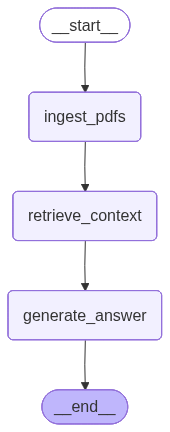

In [10]:
from langgraph.graph import START, END, StateGraph

def build_graph():
    graph_builder = StateGraph(AgentState)

    graph_builder.add_node("ingest_pdfs", ingest_pdfs_node)
    graph_builder.add_node("retrieve_context", retrieve_context_node)
    graph_builder.add_node("generate_answer", generate_answer_node)

    graph_builder.add_edge(START, "ingest_pdfs")
    graph_builder.add_edge("ingest_pdfs", "retrieve_context")
    graph_builder.add_edge("retrieve_context", "generate_answer")
    graph_builder.add_edge("generate_answer", END)

    return graph_builder.compile()

graph = build_graph()
graph


## 11. Visualize Mermaid graph


In [11]:
print(graph.get_graph().draw_mermaid())


---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	ingest_pdfs(ingest_pdfs)
	retrieve_context(retrieve_context)
	generate_answer(generate_answer)
	__end__([<p>__end__</p>]):::last
	__start__ --> ingest_pdfs;
	ingest_pdfs --> retrieve_context;
	retrieve_context --> generate_answer;
	generate_answer --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



## 12. Visualize PNG graph


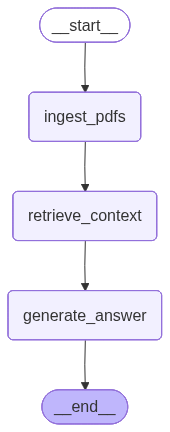

In [12]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("PNG rendering failed.")
    print("Reason:", e)


## 13. Run RAG question


In [13]:
result = graph.invoke({
    "input": "What should we check when CHECK-DOMAIN timeouts increase?"
})

print(result["answer"])


When CHECK-DOMAIN timeouts increase, you should check the following:

1. Upstream registry connectivity.
2. DNS resolver latency.
3. Client retry behavior.

If response time also increases alongside timeout volume, prioritize checking the network path and registry endpoint health before making changes to the application code. 

This information is sourced from the EPP SLA Operations Runbook (epp_runbook.pdf). Additionally, be aware that CHECK-DOMAIN latency may increase due to connection pool saturation during peak traffic hours, as noted in the EPP Release R13 Notes (epp_release_notes.pdf).


## 14. Inspect retrieved context


In [14]:
for item in result["retrieved_context"]:
    print("---")
    print(item)


---
Source: epp_runbook.pdf, page 0
EPP SLA Operations Runbook
When CHECK-DOMAIN requests show elevated CONNECTION_TIMEOUT failures, first inspect upstream
registry connectivity, DNS resolver latency, and client retry behavior.
If response_time increases together with timeout volume, prioritize network path checks and
registry endpoint health before application code changes.
For ADD-DOMAIN AUTH_FAILED spikes, inspect credential rotation, client authentication
configuration, and recent changes to access-control rules.
Recommended incident workflow: compare failure volume before and after the release window,
group failures by command and failed_reason, then identify the dominant client_name and tld.
---
Source: epp_release_notes.pdf, page 0
EPP Release R13 Notes
Release R13 was deployed from 2026-06-20 through 2026-06-22 in us-east-1.
The release included registry connection pool changes, timeout tuning, and additional
telemetry for CHECK-DOMAIN and ADD-DOMAIN commands.
Known risk: CHECK

## 15. Try release-specific question


In [15]:
result2 = graph.invoke({
    "input": "What was the known R13 risk and rollback criteria?"
})

print(result2["answer"])


The known R13 risk was that CHECK-DOMAIN latency may increase if connection pool saturation occurs during peak traffic hours. The rollback criteria were a sustained CONNECTION_TIMEOUT failure volume above baseline for two consecutive hours or a response time above 220 milliseconds for CHECK-DOMAIN. This information is sourced from the EPP Release R13 Notes (epp_release_notes.pdf).


## 16. If you still see readonly/locked DB errors

Restart the Jupyter kernel, then remove the vector DB:

```bash
rm -rf agentv12_rag_agent/chroma_db
```

Or inside the notebook, run only if no Chroma object is open:

```python
reset_vector_store()
```

Then rerun from the top.
